In [17]:
import numpy as np
import random
from typing import Union, List, Optional

def generate_onset_pattern(
    pattern: Union[float, List[float]],
    start_time: float = 0.0,
    num_events: int = 10,
    tolerance: Optional[float] = None
) -> np.ndarray:
    """
    Generates a list of onset timestamps based on a looping pattern.

    Args:
        pattern (Union[float, List[float]]): 
            The Inter-Onset Interval (IOI) pattern.
            - If float: A constant IOI that is repeated (e.g., 2.23 for a steady beat).
            - If List[float]: A sequence of IOIs that loops (e.g., [0.5, 1.0, 0.75]).
        start_time (float, optional): 
            The timestamp of the first onset. Defaults to 0.0.
        num_events (int, optional): 
            The total number of onsets to generate. Defaults to 10.
        tolerance (Optional[float], optional): 
            The maximum random deviation to apply to each IOI for a more "human" feel.
            The deviation is a random value between [-tolerance, +tolerance].
            If None, the timing is perfectly precise. Defaults to None.

    Returns:
        np.ndarray: An array of the generated onset timestamps.
    """
    if num_events <= 0:
        return np.array([])

    onset_times = [start_time]
    current_time = start_time

    # Loop to generate the remaining (num_events - 1) onsets
    for i in range(num_events - 1):
        # Determine the base IOI for this step
        if isinstance(pattern, float):
            # Case 1: The pattern is a single, constant IOI
            ioi = pattern
        else:
            # Case 2: The pattern is a list, so we loop through it
            pattern_index = i % len(pattern)
            ioi = pattern[pattern_index]
        
        # Apply random tolerance if specified
        if tolerance is not None and tolerance > 0:
            deviation = random.uniform(-tolerance, tolerance)
            ioi += deviation

        # Calculate and store the next onset time
        next_time = current_time + ioi
        onset_times.append(next_time)
        current_time = next_time
        
    return np.array(onset_times)

In [57]:

generated_onsets = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.01 
)

generated_onsets2 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.02 
)

generated_onsets3 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.05 
)

vocal_cues = generate_onset_pattern(
    pattern=[4.0, 0.5, 0.5], # A long pause followed by two quick entries
    start_time=2.0,
    num_events=6,
    tolerance=0.1
)

# 3. Structure them into the dictionary for plotting
onset_times_dict = {
    "Generated Onsets": {
        "times": generated_onsets,
        "color": "cyan"
    }
}

# 4. Plot them!
visualize_features(
    features=feature_data,              
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend='bokeh' # or 'bokeh'
)

In [42]:
print(generated_onsets)

[ 0.4         2.63110864  4.86086156  7.09688095  9.33748171 11.56321503
 13.80171725 16.04174928 18.27769352 20.50331143 22.74194354 24.98239591
 27.22175799 29.45841396 31.69010248 33.91819201 36.14598739 38.37124753
 40.60832549 42.84853919 45.08630259 47.3134205  49.53817942 51.77983327
 54.01691919 56.24369098 58.47756474 60.71987642 62.9434892  65.17409125
 67.41125657 69.63955383]


In [1]:
import pandas as pd

df1 = pd.read_csv('examples_csv/dufour_manual.csv')
display(df1)

df2 = pd.read_csv('examples_csv/dufour_onsets_librosa_filtered.csv')
display(df2)


,peaks_in_sec
0,0.398730
1,2.623492
2,4.863492
3,7.080635
4,9.340952
5,11.553016
6,13.782857
7,16.017778
8,18.245079
9,20.490159


,seq1
0,0.400544
1,2.618050
2,4.858776
3,7.082086
4,9.322812
5,11.528707
6,13.775238
7,16.015964
8,18.210249
9,20.485805


In [2]:
onset_times1 = df1['peaks_in_sec'].tolist()
print(onset_times1)

onset_times2 = df2['seq1'].tolist()
print(onset_times2)

[0.398730159, 2.623492063, 4.863492063, 7.080634921, 9.340952381, 11.553015873, 13.782857143, 16.017777778, 18.245079365, 20.49015873, 22.70984127, 24.954920635, 27.182222222, 29.424761905, 31.641904762, 33.881904762, 36.12952381, 38.38984127, 40.604444444, 42.852063492, 45.074285714, 47.311746032, 49.536507937, 51.781587302, 53.998730159, 56.236190476, 58.466031746, 60.693333333, 62.938412698, 65.158095238, 67.408253968, 69.627936508]
[0.4005442176870748, 2.618049886621315, 4.858775510204081, 7.082086167800454, 9.32281179138322, 11.528707482993198, 13.775238095238096, 16.015963718820863, 18.210249433106576, 20.48580498866213, 22.709115646258503, 24.9556462585034, 27.17315192743764, 29.41968253968254, 31.642993197278912, 33.88952380952381, 36.11283446712018, 38.376780045351474, 40.600090702947846, 42.84081632653061, 45.06993197278912, 47.31065759637188, 49.533968253968254, 51.78049886621315, 53.9980045351474, 56.24453514739229, 58.46784580498866, 60.67374149659864, 62.93768707482993, 6

In [59]:


# The new data structure for our functions
cue_lists = {
    "Manual Ground Truth": onset_times1,
    # "Librosa Onsets": onset_times2,
    "Generated Onsets, tol=0.01": generated_onsets,
    "Generated Onsets 2, tol=0.02": generated_onsets2,
    "Generated Onsets 3, tol=0.05": generated_onsets3
}

# The key for the reference list
ground_truth_key = "Manual Ground Truth" 

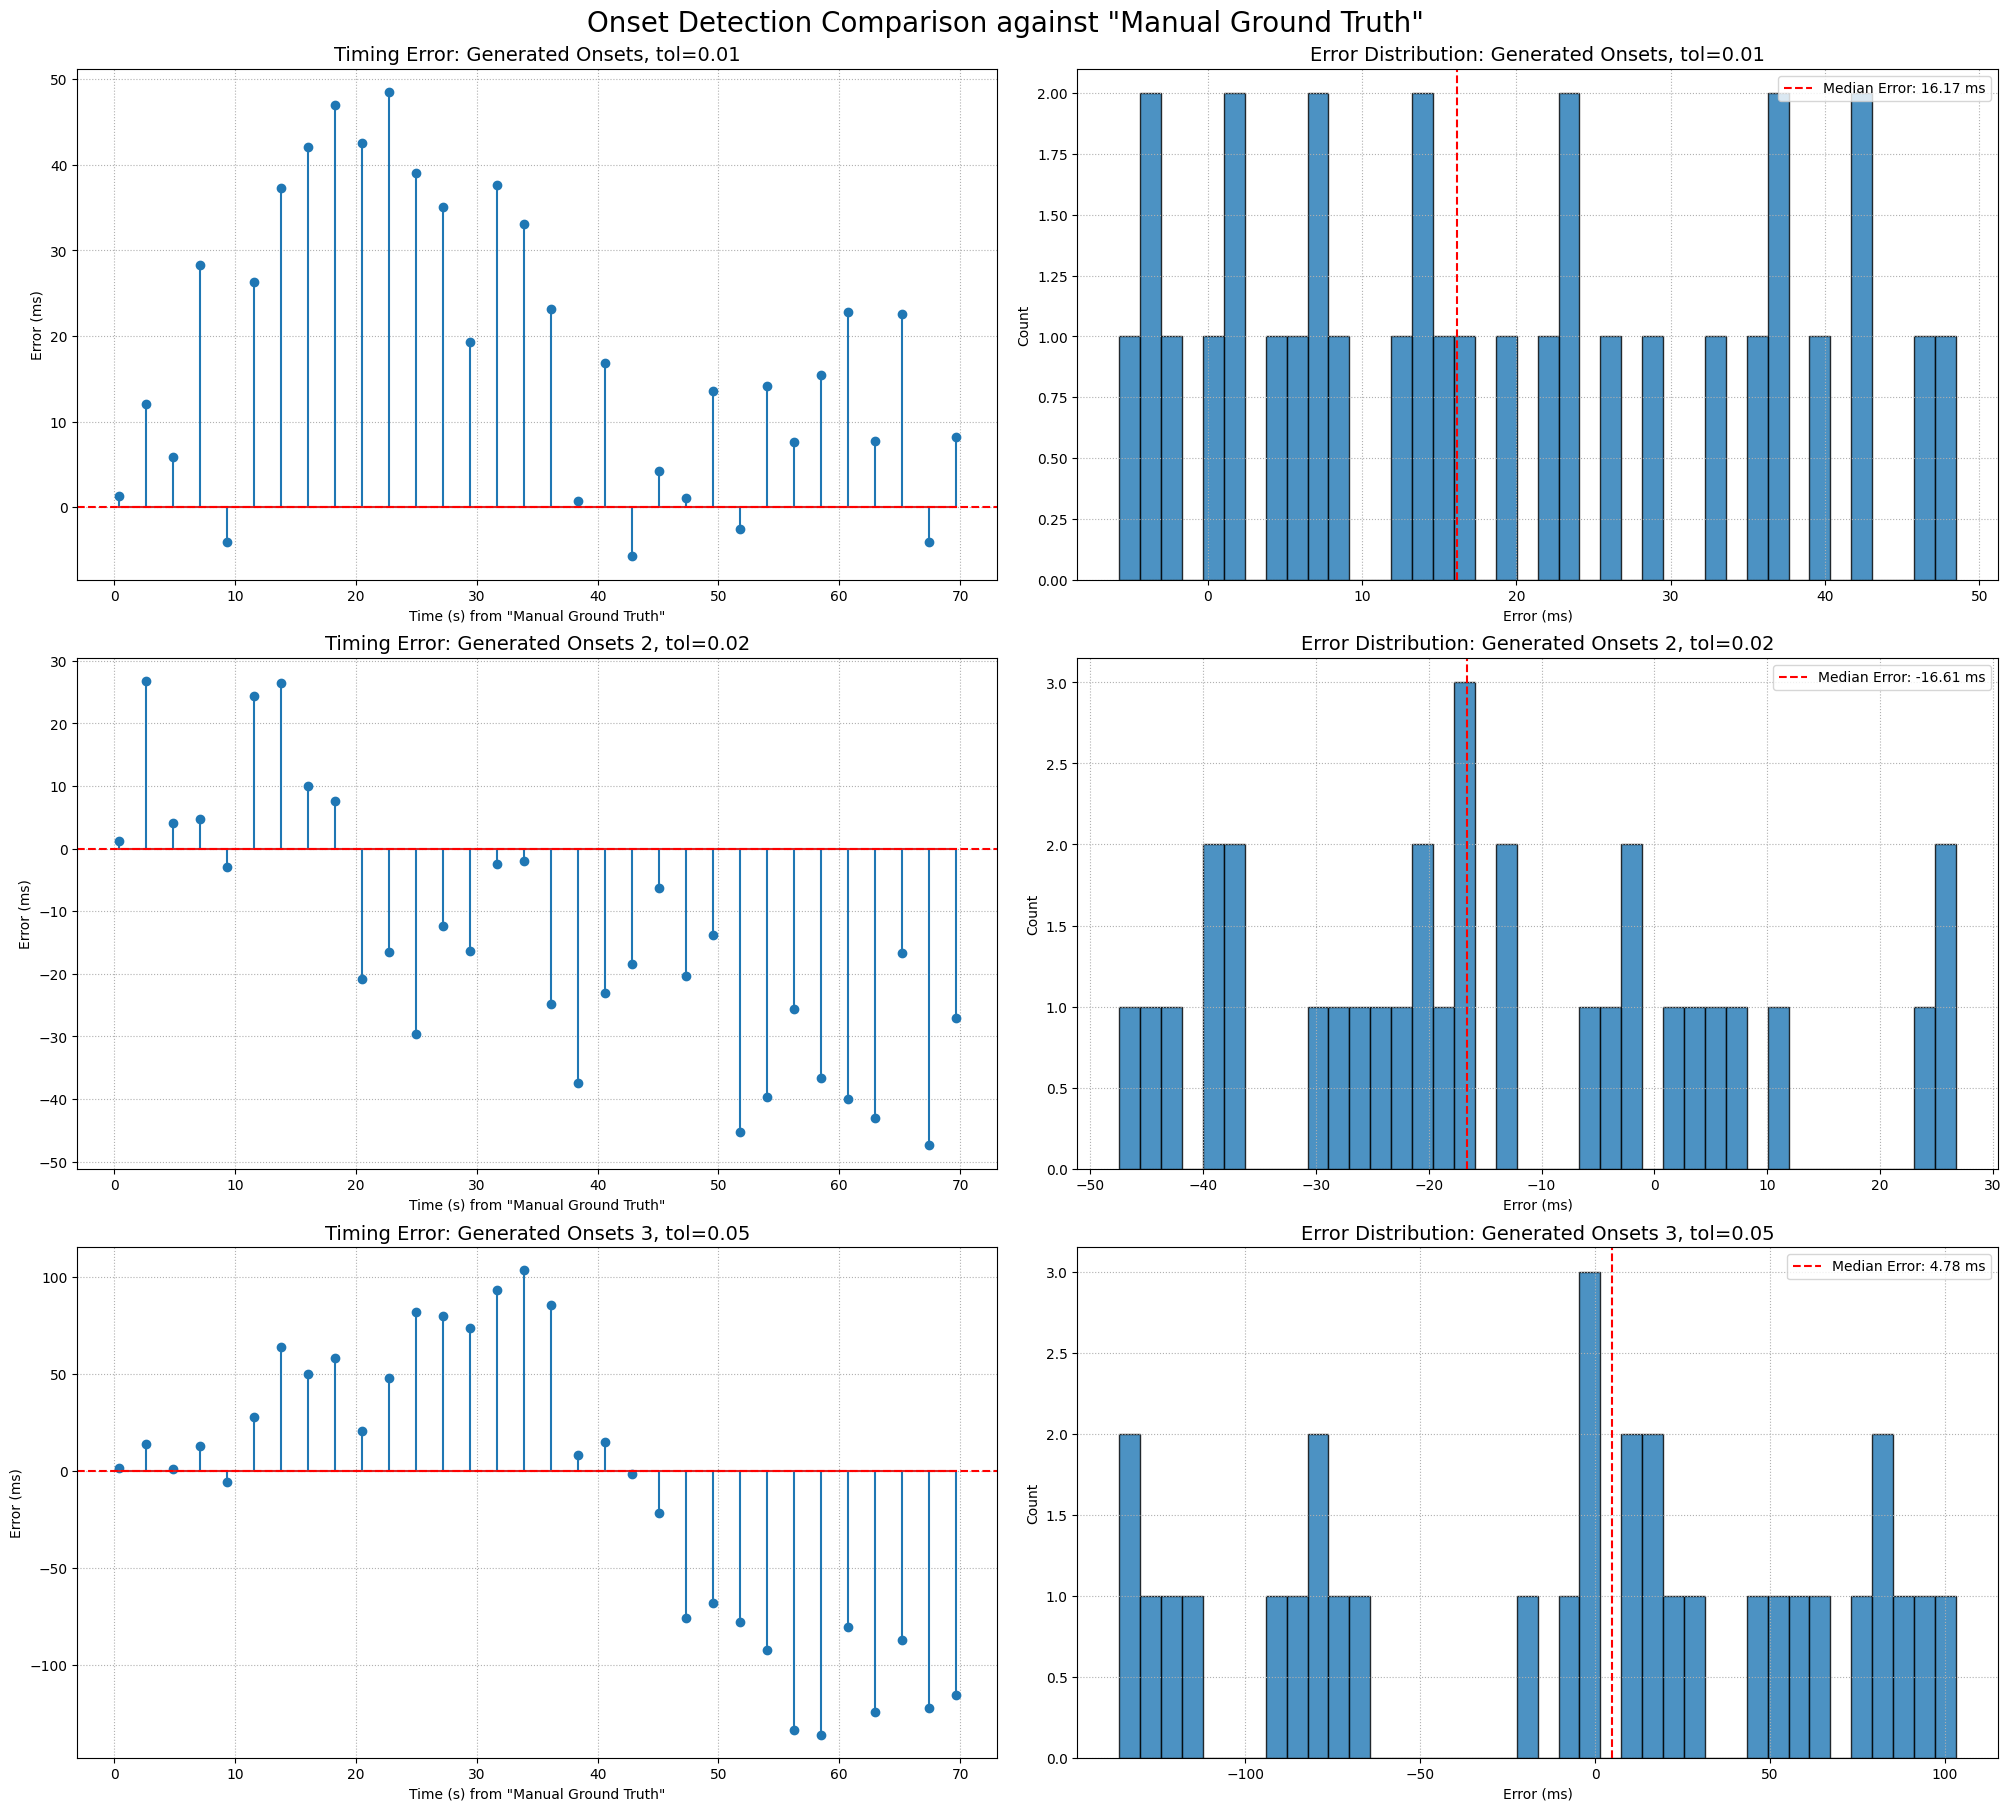

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List

def visualize_multi_onset_differences(
    cue_lists: Dict[str, List[float]], 
    ground_truth_key: str
):
    """
    Creates a dashboard to compare multiple detected onset lists against a single ground truth,
    using constrained_layout for robust spacing.
    """
    if ground_truth_key not in cue_lists:
        raise ValueError(f"The ground_truth_key '{ground_truth_key}' was not found in the cue_lists dictionary.")

    truth_times = np.array(cue_lists[ground_truth_key])
    detected_keys = [key for key in cue_lists if key != ground_truth_key]
    
    if not detected_keys:
        print("No other lists to compare against the ground truth.")
        return

    n_rows = len(detected_keys)
    
    # --- The key change is enabling constrained_layout=True here ---
    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 6 * n_rows), 
                             squeeze=False, constrained_layout=True)
                             
    fig.suptitle(f'Onset Detection Comparison against "{ground_truth_key}"', fontsize=20)

    for i, key in enumerate(detected_keys):
        # ... (The rest of the plotting logic inside the loop is identical) ...
        detected_times = np.array(cue_lists[key])
        min_len = min(len(truth_times), len(detected_times))
        truth_sliced = truth_times[:min_len]
        detected_sliced = detected_times[:min_len]
        error_ms = (detected_sliced - truth_sliced) * 1000

        # Plot 1: Timing Error
        ax1 = axes[i, 0]
        ax1.stem(truth_sliced, error_ms)
        ax1.axhline(0, color='r', linestyle='--')
        ax1.set_title(f'Timing Error: {key}', fontsize=14)
        ax1.set_xlabel(f'Time (s) from "{ground_truth_key}"')
        ax1.set_ylabel('Error (ms)')
        ax1.grid(True, linestyle=':')

        # Plot 2: Histogram
        ax2 = axes[i, 1]
        ax2.hist(error_ms, bins=40, alpha=0.8, edgecolor='black')
        median_error = np.median(error_ms)
        ax2.axvline(median_error, color='r', linestyle='--', label=f'Median Error: {median_error:.2f} ms')
        ax2.set_title(f'Error Distribution: {key}', fontsize=14)
        ax2.set_xlabel('Error (ms)')
        ax2.set_ylabel('Count')
        ax2.legend()
        ax2.grid(True, linestyle=':')

    # --- The old tight_layout() call is removed ---
    plt.show()

# --- HOW TO USE ---
visualize_multi_onset_differences(cue_lists, ground_truth_key)

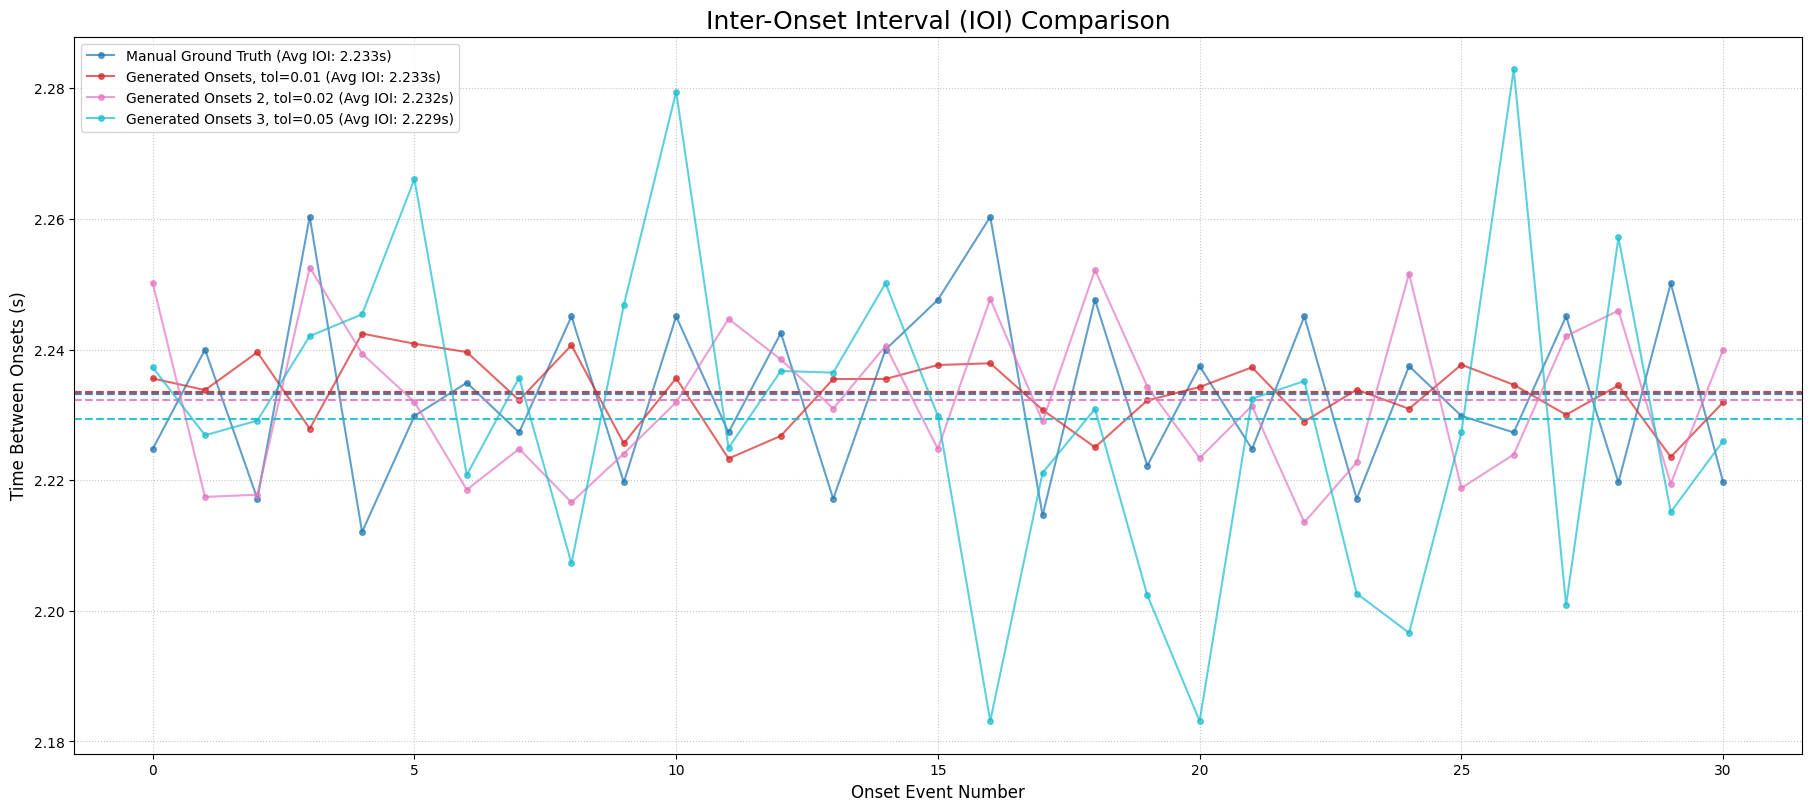

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_multi_ioi_comparison(cue_lists: Dict[str, List[float]]):
    """
    Calculates and plots the Inter-Onset Intervals (IOI) for multiple lists,
    using constrained_layout for robust legend placement.
    """
    # The key change is creating the figure and axes with constrained_layout=True
    fig, ax = plt.subplots(figsize=(18, 8), constrained_layout=True)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(cue_lists)))

    for i, (label, times) in enumerate(cue_lists.items()):
        if len(times) < 2:
            print(f"Warning: List '{label}' has fewer than 2 onsets, cannot calculate IOI. Skipping.")
            continue
            
        ioi = np.diff(np.array(times))
        avg_ioi = np.mean(ioi)
        legend_label = f'{label} (Avg IOI: {avg_ioi:.3f}s)'
        
        ax.plot(ioi, marker='o', linestyle='-', markersize=4, 
                label=legend_label, color=colors[i], alpha=0.7)
        ax.axhline(y=avg_ioi, color=colors[i], linestyle='--', alpha=0.9)

    ax.set_title('Inter-Onset Interval (IOI) Comparison', fontsize=18)
    ax.set_xlabel('Onset Event Number', fontsize=12)
    ax.set_ylabel('Time Between Onsets (s)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # A simple legend call is now sufficient. constrained_layout will make room for it.
    ax.legend()
    
    # We no longer need the plt.tight_layout() call.
    plt.show()

# --- HOW TO USE ---
plot_multi_ioi_comparison(cue_lists)

In [ ]:
# Save selected sequence as CSV

import os

# 1. Define the filename
filename = "best_sequence.csv"

# 2. Save the array to the CSV file
np.savetxt(filename, best_seq, delimiter=",")

# 3. Get the full, absolute path of the file
full_path = os.path.abspath(filename)

# 4. Print the confirmation message with the full path
print(f"The best sequence has been saved to: {full_path}")

In [21]:
onset_times_dict = {
    "manual": {
        "times": onset_times1,
        "color": "red"
    },
    "librosa": {
        "times": onset_times2,
        "color": "magenta"
    }
}

In [22]:
# Import the necessary functions from your module
from py_scripts.audio_visualizer import load_audio, extract_features, visualize_features
import numpy as np

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---

# --- CONFIGURATION ---
AUDIO_PATH = 'examples_audio/Dufour_full_mono.aif'
HOP_LENGTH = 128
N_FFT = 2048

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH)

# 2. Define which features you want to compute and plot

# Features: 'waveform', 'stft_db', 'spec_db', 'amplitude_envelope', 'zero_crossing_rate', 
# 'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
# 'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'

FEATURES_TO_PLOT = ['waveform', 'spectral_centroid', 'amplitude_envelope']

# 3. COMPUTE THE FEATURES from the audio signal
# This will return a dictionary like {'waveform': [...], 'stft_db': [...], ...}
feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)

# 4. Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'bokeh'

# 5. Plot the computed features
visualize_features(
    features=feature_data,              
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND            
)


Loading BokehJS ...

Loaded 'examples_audio/Dufour_full_mono.aif' -> 77.67s @ 44100Hz
